In [2]:
import mdtraj as md
from matplotlib import pyplot as plt
import numpy as np

import sys
import random
import seaborn as sb
import scipy.stats as st
from collections import Counter
import matplotlib as mpl

In [7]:
topology='/Users/belayv/Downloads/gssg_data_final/step5_input.pdb'
# Define individual trajectories for pose 2
def load_trajectories():
    traj2_1=md.load('/Users/belayv/Downloads/gssg_data_final/1.dcd',top=topology)
    traj2_2=md.load('/Users/belayv/Downloads/gssg_data_final/2.dcd',top=topology)
    traj2_3=md.load('/Users/belayv/Downloads/gssg_data_final/3.dcd',top=topology)
    traj2_4=md.load('/Users/belayv/Downloads/gssg_data_final/4.dcd',top=topology)
    traj2_5=md.load('/Users/belayv/Downloads/gssg_data_final/5.dcd',top=topology)
    traj2_6=md.load('/Users/belayv/Downloads/gssg_data_final/6.dcd',top=topology)
    traj2_7=md.load('/Users/belayv/Downloads/gssg_data_final/7.dcd',top=topology)
    traj2_8=md.load('/Users/belayv/Downloads/gssg_data_final/8.dcd',top=topology)
    traj2_9=md.load('/Users/belayv/Downloads/gssg_data_final/9.dcd',top=topology)
    traj2_12=md.load('/Users/belayv/Downloads/gssg_data_final/12.dcd',top=topology)
    traj2_13=md.load('/Users/belayv/Downloads/gssg_data_final/13.dcd',top=topology)
    
    return [traj2_1,traj2_2,traj2_3,traj2_4,traj2_5,traj2_6,traj2_7,traj2_8,traj2_9,traj2_1,traj2_13]

In [4]:
# Define RMSD computation function
def compute_rmsd(traj, reference=None):
    """
    Compute RMSD for a trajectory
    Args:
        traj: MDTraj trajectory object
        reference: Reference structure (defaults to first frame)
    Returns:
        rmsd: Array of RMSD values in Angstroms
    """
    if reference is None:
        reference = traj[0]
    backbone_indices = traj.topology.select('protein and name CA')
    rmsd = md.rmsd(traj, reference, atom_indices=backbone_indices) * 10  # Convert to Angstroms
    return rmsd

In [ ]:
def process_trajectories(trajs):
    """
    Process trajectories and compute RMSD
    Args:
        trajs: List of trajectory objects
    Returns:
        all_rmsd: List of RMSD arrays truncated to same length
    """
    # Print trajectory lengths
    for i, traj in enumerate(trajs):
        print(f"Length of trajectory {i+1}: {len(traj)} frames")
    
    # Find minimum length across all trajectories
    min_length = min(len(traj) for traj in trajs)
    print(f"Truncating all trajectories to {min_length} frames")
    
    # Calculate RMSD for each trajectory and truncate to minimum length
    all_rmsd = []
    for traj in trajs:
        rmsd = compute_rmsd(traj)
        all_rmsd.append(rmsd[:min_length])


     # Calculate statistics
    mean_rmsd = np.mean(all_rmsd, axis=0)
    std_error = st.sem(all_rmsd, axis=0)
    ci_95 = 1.96 * std_error
    
    # Create time axis (assuming 1 frame = 1 ns, adjust if different)
    time = np.linspace(0, len(mean_rmsd), len(mean_rmsd))
    
    return np.array(all_rmsd), mean_rmsd, ci_95


In [8]:
# Load trajectories
print("Loading trajectories...")
trajs = load_trajectories()

# Join trajectories (if needed)
trajs_joined = md.join(trajs)

# Process trajectories and compute RMSD
print("Computing RMSD...")
all_rmsd = process_trajectories(trajs)


Loading trajectories...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD

Text(0.5, 1.0, 'Average RMSD with 95% Confidence Interval')

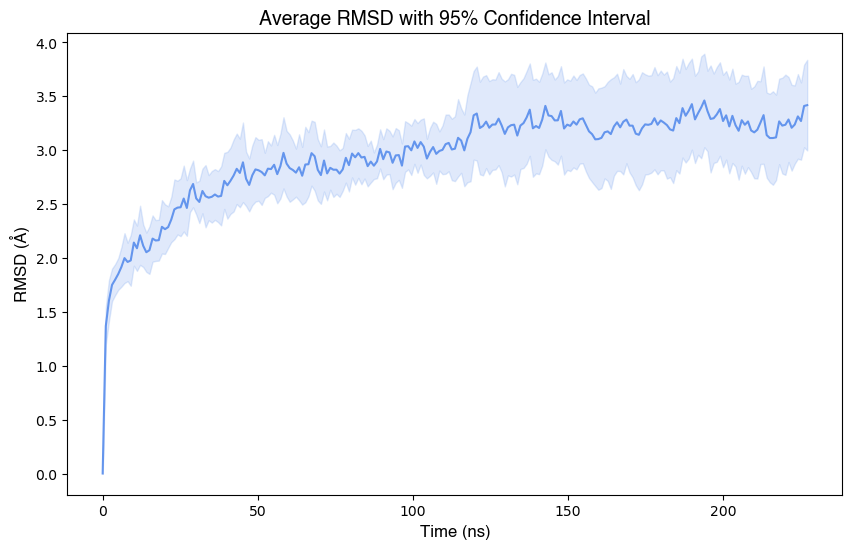

In [12]:
mean_rmsd= np.mean(all_rmsd, axis=0)
ci_95 = 1.96 * st.sem(all_rmsd, axis=0)
# Create time axis (assuming 1 frame = 1 ns, adjust if different)
time = np.linspace(0, len(mean_rmsd), len(mean_rmsd))

# Create plot with specific font settings
plt.figure(figsize=(10, 6))

# Plot data
plt.plot(time, mean_rmsd, label='Mean RMSD', color='cornflowerblue')
plt.fill_between(time, 
                    mean_rmsd - ci_95, 
                    mean_rmsd + ci_95, 
                    color='cornflowerblue', 
                    alpha=0.2, 
                    label='95% CI')

# Set labels with specific font
plt.xlabel('Time (ns)', fontname='Helvetica', fontsize=12)
plt.ylabel('RMSD (Å)', fontname='Helvetica', fontsize=12)
plt.title('Average RMSD with 95% Confidence Interval', 
            fontname='Helvetica', 
            fontsize=14)


In [14]:
import pandas as pd

# Assuming you have already called the function:
# all_rmsd, mean_rmsd, ci_95 = process_trajectories(trajs)

def export_rmsd_to_csv(mean_rmsd, ci_95, filename="/Users/belayv/Downloads/rmsd_data.csv"):
    # Calculate the bounds
    lower_bound = mean_rmsd - ci_95
    upper_bound = mean_rmsd + ci_95
    
    # Create a time axis consistent with your function
    time = np.linspace(0, len(mean_rmsd), len(mean_rmsd))
    
    # Create a DataFrame
    df = pd.DataFrame({
        'Time_ns': time,
        'Mean_RMSD': mean_rmsd,
        'CI_95_Lower': lower_bound,
        'CI_95_Upper': upper_bound
    })
    
    # Export to CSV
    df.to_csv(filename, index=False)
    print(f"Data successfully exported to {filename}")

# Usage
export_rmsd_to_csv(mean_rmsd, ci_95)

Data successfully exported to /Users/belayv/Downloads/rmsd_data.csv
